# 链接预测 —— FB15k-237 知识图谱

**任务定义**：给定头实体 $h$ 和关系 $r$，预测缺失的尾实体 $t$（或给定尾实体和关系预测头实体）。即对查询 $(h, r, ?)$ 或 $(?, r, t)$，在所有候选实体中排序，使得正确答案排名尽可能靠前。

**数据集**：FB15k-237 是从 Freebase 知识库中抽取的子集，涵盖电影、音乐、体育、奖项、地理、组织等多个现实世界领域。

| 指标 | 数值 |
|------|------|
| 实体数 | 14,541 |
| 关系数 | 237 |
| 训练三元组 | 272,115 |
| 验证三元组 | 17,535 |
| 测试三元组 | 20,466 |

**评估指标**：MRR（Mean Reciprocal Rank）、Hits@1、Hits@3、Hits@10。所有排名均使用 filtered 设置。

**模型**：TransE —— 将关系建模为头实体到尾实体的平移向量，得分函数 $\gamma - \|\mathbf{h} + \mathbf{r} - \mathbf{t}\|_p$。

In [1]:
import sys
import time
import tempfile
import shutil
from collections import Counter
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt

_project_root = Path().resolve().parent
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

from kge.config.loader import from_yaml
from kge.datasets import load_dataset, KGDataModule
from kge.models import build_model
from kge.trainer import create_trainer
from core.utils import get_device

from kge.notebooks import (
    plot_training_curves,
    plot_triple_split_summary,
    plot_relation_performance,
    plot_relation_category_analysis,
    plot_tsne_embeddings,
    parse_fb_relation_domain,
    format_relation_name,
    classify_relation_cardinality,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 100

cfg = from_yaml("config/link_prediction-baseline.yaml")
print(f"任务: {cfg.task.value} | 编码器: {cfg.model.encoder_name} | 数据集: {cfg.dataset.name}")
print(f"嵌入维度: {cfg.model.params.get('embedding_dim', 100)} | 负采样数: {cfg.dataset.num_negative_samples}")
print(f"损失函数: {cfg.train.loss_type.value} | 最大 epoch: {cfg.train.epochs}")

任务: link_prediction | 编码器: trans-e | 数据集: fb15k-237
嵌入维度: 100 | 负采样数: 128
损失函数: margin_ranking | 最大 epoch: 500


## 数据探索

FB15k-237 中的关系反映了 Freebase 知识库的真实语义结构。关系名采用路径格式（如 `/film/film/language`），可以从路径中解析出所属领域。下面查看数据的基本统计和样本。

实体数量: 14,541
关系数量: 237
训练三元组: 272,115
验证三元组: 17,535
测试三元组: 20,466


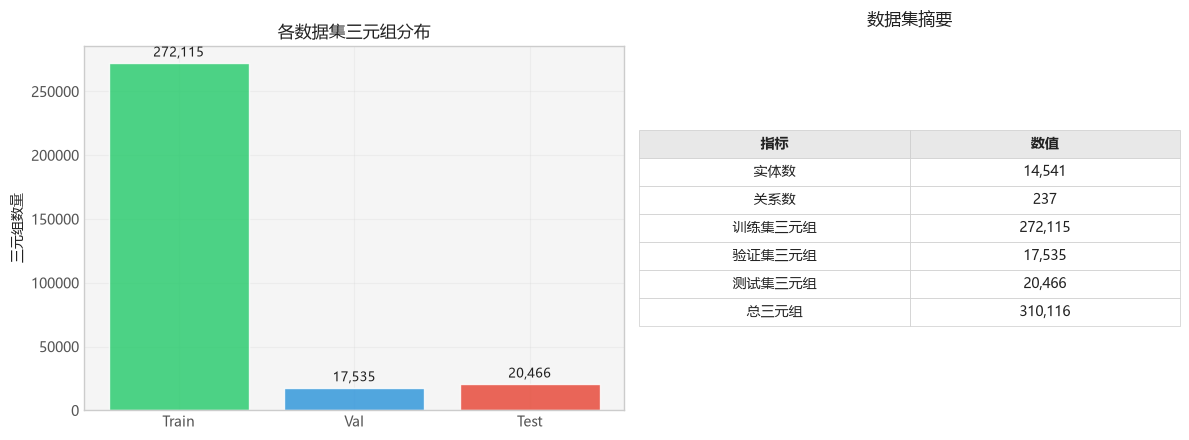


样本三元组（前 8 条训练数据）：
  (/m/027rn, location/country/form_of_government, /m/06cx9)
  (/m/017dcd, tv/tv_program/regular_cast./tv/regular_tv_appearance/ac, /m/06v8s0)
  (/m/07s9rl0, media_common/netflix_genre/titles, /m/0170z3)
  (/m/01sl1q, award/award_winner/awards_won./award/award_honor/award_, /m/044mz_)
  (/m/0cnk2q, soccer/football_team/current_roster./sports/sports_team, /m/02nzb8)
  (/m/04nrcg, soccer/football_team/current_roster./soccer/football_ro, /m/02sdk9v)
  (/m/07nznf, film/actor/film./film/performance/film, /m/014lc_)
  (/m/02qyp19, award/award_category/nominees./award/award_nomination/n, /m/02d413)

最高频关系 Top-5:
  award/award_nominee/award_nominations./award/award_nominatio: 15,989
  film/film/release_date_s./film/film_regional_release_date/fi: 12,893
  award/award_nominee/award_nominations./award/award_nominatio: 12,157
  people/person/profession: 10,945
  film/actor/film./film/performance/film: 9,494

最低频关系 Bottom-5:
  music/instrument/family: 100
  dataworld/gardening_hin

In [2]:
dataset = load_dataset(cfg.dataset.name, cfg.dataset.root)

print(f"实体数量: {dataset.num_entities:,}")
print(f"关系数量: {dataset.num_relations:,}")
print(f"训练三元组: {len(dataset.train_triples):,}")
print(f"验证三元组: {len(dataset.val_triples):,}")
print(f"测试三元组: {len(dataset.test_triples):,}")

fig = plot_triple_split_summary(dataset)
plt.show()

id2ent = dataset.id_to_entity
id2rel = dataset.get_id_to_relation

print("\n样本三元组（前 8 条训练数据）：")
for i in range(8):
    h, r, t = dataset.train_triples[i].tolist()
    r_name = format_relation_name(id2rel[r])
    print(f"  ({id2ent[h][:25]}, {r_name[:55]}, {id2ent[t][:25]})")

rel_counter = Counter()
for triple in dataset.train_triples:
    rel_counter[int(triple[1])] += 1

print(f"\n最高频关系 Top-5:")
for rid, count in rel_counter.most_common(5):
    print(f"  {format_relation_name(id2rel[rid])[:60]}: {count:,}")

print(f"\n最低频关系 Bottom-5:")
for rid, count in rel_counter.most_common()[-5:]:
    print(f"  {format_relation_name(id2rel[rid])[:60]}: {count:,}")

# 域分布
domain_counter = Counter()
for rid in rel_counter:
    domain = parse_fb_relation_domain(id2rel[rid])
    domain_counter[domain] += 1
print(f"\n关系领域分布（共 {len(domain_counter)} 个域）:")
for domain, count in domain_counter.most_common():
    print(f"  {domain}: {count} 个关系")

## 模型架构

**TransE**（Bordes et al., 2013）是最经典的 KGE 模型。核心思想：对于真实三元组 $(h, r, t)$，期望 $\mathbf{h} + \mathbf{r} \approx \mathbf{t}$。

- **得分函数**：$f(h, r, t) = \gamma - \|\mathbf{h} + \mathbf{r} - \mathbf{t}\|_p$
- **LinkPredictionHead**：直接委托给 `encoder.score()`，不引入额外参数
- **负采样**：Uniform Negative Sampling，128 个负例 / 正例，50% 概率替换头实体或尾实体
- **损失函数**：Margin Ranking Loss $\mathcal{L} = \sum \max(0, \text{margin} - f_+ + f_-)$
- **评估协议**：Filtered Ranking —— 在排序时屏蔽其他已知真三元组

In [3]:
device = get_device(cfg.runtime.device)
print(f"设备: {device}")

data_module = KGDataModule(cfg, dataset)
model = build_model(cfg, dataset.num_entities, dataset.num_relations)

total_params = sum(p.numel() for p in model.parameters())
print(f"模型参数量: {total_params:,}")
print(f"  实体嵌入: {model.encoder.entity_embedding.weight.numel():,}")
print(f"  关系嵌入: {model.encoder.relation_embedding.weight.numel():,}")

trainer = create_trainer(cfg, model, data_module, device)

checkpoint_dir = Path(tempfile.mkdtemp(prefix="kge_lp_"))
print(f"Checkpoint 目录: {checkpoint_dir}")

torch.manual_seed(42)
t0 = time.perf_counter()
history = trainer.train(checkpoint_dir)
elapsed = time.perf_counter() - t0
print(f"训练耗时: {elapsed:.1f}s")

shutil.rmtree(checkpoint_dir, ignore_errors=True)

设备: cpu
模型参数量: 1,477,800
  实体嵌入: 1,454,100
  关系嵌入: 23,700
Checkpoint 目录: C:\Users\10494\AppData\Local\Temp\kge_lp_jruugo9v


KeyboardInterrupt: 

## 训练曲线

链接预测训练器在评估时不计算 val_loss（仅计算 MRR / Hits@K 等排序指标），因此左图只展示训练损失的下降趋势。右图展示 MRR 随训练的变化，包括 train MRR（直接在训练 batch 上计算）和 val MRR（在验证集上的过滤排序评估）。

In [ ]:
fig = plot_training_curves(
    history, metric_key="mrr", metric_label="MRR", loss_mode="train_loss_only"
)
plt.show()

for k in sorted(history):
    if k.startswith("test_"):
        print(f"Test {k.replace('test_', '').upper()}: {history[k][0]:.4f}")

## 各关系性能分析

不同关系的预测难度差异显著。例如，一对多关系（如 `film/performance/film`，一个演员出演多部电影）通常比一对一关系更难预测。下面在测试集上逐关系评估 MRR，找出模型最擅长和最不擅长的关系类型。

In [ ]:
from kge.utils.metrics import ranks, mrr, hits_at_k

@torch.no_grad()
def eval_per_relation(model, data_module, dataset, device):
    model.eval()
    encoder = model.encoder
    test_triples = dataset.test_triples.to(device)
    filter_set = data_module.filter_set
    bs = 256

    all_ranks, all_relations = [], []
    for i in range(0, len(test_triples), bs):
        batch = test_triples[i:i + bs]
        h, r, t = batch[:, 0], batch[:, 1], batch[:, 2]

        scores_tail = encoder.score_all_tails(h, r)
        rank_tail = ranks(scores_tail, t, filter_set, h, r)
        all_ranks.append(rank_tail); all_relations.append(r)

        scores_head = encoder.score_all_tails(t, r)
        rank_head = ranks(scores_head, h, filter_set, t, r)
        all_ranks.append(rank_head); all_relations.append(r)

    all_ranks = torch.cat(all_ranks).cpu()
    all_relations = torch.cat(all_relations).cpu()

    id2rel = dataset.get_id_to_relation
    per_rel = {}
    for rid in all_relations.unique().tolist():
        mask = all_relations == rid
        rel_ranks = all_ranks[mask]
        per_rel[rid] = {
            "name": format_relation_name(id2rel[rid]),
            "count": int(mask.sum()),
            "mrr": mrr(rel_ranks),
        }
    return per_rel

per_rel = eval_per_relation(model, data_module, dataset, device)

sorted_rel = sorted(per_rel.items(), key=lambda x: x[1]["mrr"])
print("=== MRR 最低的 5 个关系 ===")
for rid, info in sorted_rel[:5]:
    print(f"  {info['name'][:55]}: MRR={info['mrr']:.4f}, n={info['count']}")

print("\n=== MRR 最高的 5 个关系 ===")
for rid, info in sorted_rel[-5:]:
    print(f"  {info['name'][:55]}: MRR={info['mrr']:.4f}, n={info['count']}")

rel_names = [info["name"] for _, info in sorted_rel]
rel_mrrs = [info["mrr"] for _, info in sorted_rel]
fig = plot_relation_performance(
    rel_names, rel_mrrs,
    title="各关系链接预测 MRR（FB15k-237）",
    metric_name="MRR", top_n=15,
)
plt.show()

## 关系领域分析

FB15k-237 的 237 个关系分属不同的语义领域。将关系按域名（`/film/`, `/music/`, `/sports/` 等）分组，观察哪个领域的知识更容易被模型捕捉。

In [ ]:
id2rel = dataset.get_id_to_relation

domain_metrics: dict[str, list[float]] = {}
for rid, info in per_rel.items():
    domain = parse_fb_relation_domain(id2rel[rid])
    domain_metrics.setdefault(domain, []).append(info["mrr"])

domain_metrics = {d: vals for d, vals in domain_metrics.items() if len(vals) >= 2}

fig = plot_relation_category_analysis(domain_metrics, metric_name="MRR")
plt.show()

print("各领域 MRR 均值:")
for cat, vals in sorted(domain_metrics.items(), key=lambda x: np.mean(x[1]), reverse=True):
    print(f"  {cat:20s}: mean={np.mean(vals):.4f}, std={np.std(vals):.4f}, n={len(vals)}")

## 关系基数类型分析

根据 `KGDataModule` 计算的 TPH（tail-per-head）和 HPT（head-per-tail）统计量，将每个关系分类为四种基数模式：
- **1-1**：每个头实体对应约 1 个尾实体，反之亦然（如 `country/capital`）
- **1-N**：头实体对应多个尾实体（如 `film/actors`）
- **N-1**：多个头实体对应同尾实体（如 `person/nationality` 的反向）
- **N-N**：多对多关系，预测最难

下面分析不同基数类型对 MRR 的影响。

In [ ]:
tph = data_module.tph.cpu()
hpt = data_module.hpt.cpu()

cardinality_metrics: dict[str, list[float]] = {"1-1": [], "1-N": [], "N-1": [], "N-N": []}
for rid, info in per_rel.items():
    cat = classify_relation_cardinality(tph[rid].item(), hpt[rid].item())
    cardinality_metrics[cat].append(info["mrr"])

fig, ax = plt.subplots(figsize=(7, 4.5))
fig.patch.set_facecolor("#ffffff")

order = ["1-1", "1-N", "N-1", "N-N"]
colors = ["#2ecc71", "#3498db", "#f39c12", "#e74c3c"]
for i, cat in enumerate(order):
    vals = cardinality_metrics[cat]
    if vals:
        ax.bar(i, np.mean(vals), yerr=np.std(vals), color=colors[i], alpha=0.8,
               capsize=5, label=f"{cat} (n={len(vals)})")

ax.set_xticks(range(len(order)))
ax.set_xticklabels(order)
ax.set_ylabel("MRR")
ax.set_title("不同基数类型的链接预测 MRR")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, axis="y")
fig.tight_layout()
plt.show()

for cat in order:
    vals = cardinality_metrics[cat]
    if vals:
        print(f"{cat}: 关系数={len(vals)}, 平均 MRR={np.mean(vals):.4f} ± {np.std(vals):.4f}")

## 实体嵌入可视化

用 t-SNE 将实体嵌入降维到二维空间，按实体度数（参与三元组的数量）着色。高度数实体通常是知识图谱中的“枢纽”节点（如著名演员、大城市），它们往往位于嵌入空间的中心区域。

In [ ]:
entity_embeddings = model.encoder.entity_embedding.weight.detach().cpu()

entity_degree = torch.zeros(dataset.num_entities, dtype=torch.long)
for triple in dataset.train_triples:
    h, _, t = triple.tolist()
    entity_degree[h] += 1
    entity_degree[t] += 1

fig = plot_tsne_embeddings(
    entity_embeddings, entity_degree,
    title="FB15k-237 实体嵌入 t-SNE 可视化（按度数着色）",
    color_map="plasma",
)
plt.show()

print(f"实体度数分布: min={entity_degree.min().item()}, "
      f"median={entity_degree.median().item():.0f}, max={entity_degree.max().item()}")

## 总结

本 notebook 演示了在 FB15k-237 上使用 TransE 进行链接预测的完整流程：

1. **数据层面**：FB15k-237 涵盖 237 种关系、横跨 30+ 个语义领域，关系频率和基数类型差异巨大
2. **模型层面**：TransE 作为最简单的平移模型，参数量仅 `(N_e + N_r) × d`，在 FB15k-237 上可通过早停在 ~100-200 个 epoch 内收敛
3. **性能分析**：
   - 一对一关系（如唯一标识属性）预测精度最高
   - 多对多关系（如 `film/performance/film`）天然更困难
   - 低频关系由于训练数据不足，MRR 显著偏低
4. **嵌入空间**：t-SNE 可视化显示高度数实体（枢纽节点）倾向于聚集在嵌入空间中心

**后续优化方向**：更换更强的 encoder（RotatE、PairRE）、使用自对抗负采样、调整嵌入维度、增加正则化。